In [1]:

!pip -q install statsmodels >/dev/null 2>&1
!apt -qq install fonts-nanum -y >/dev/null 2>&1

import pandas as pd, numpy as np, warnings, glob
import matplotlib.pyplot as plt, matplotlib.font_manager as fm
from scipy import stats
from statsmodels.stats.multitest import multipletests
warnings.filterwarnings('ignore')

for f in glob.glob('/usr/share/fonts/truetype/nanum/*.ttf'):
    fm.fontManager.addfont(f)
plt.rc('font', family='NanumBarunGothic')
plt.rc('axes', unicode_minus=False)
plt.rcParams.update({'figure.dpi':120, 'axes.spines.top':False, 'axes.spines.right':False})

BURG = ['#F2E4E7','#D9A3AE','#B85C6E','#8B2E3F','#5C1526']
MAIN, GREY = '#8B2E3F', '#9E9E9E'

PATH = '/content/FDA_adverse_events_final.csv'
df = pd.read_csv(PATH, low_memory=False)
print('로드:', df.shape)


로드: (18273, 28)


In [2]:
#G군 식별 (소아 + 감기 + APAP 복합)
# 표의 G "Children's Tylenol Cold/Flu류" = 소아용 + 감기 표기 + 아세트아미노펜 복합.
# 단일 덱스트로메토르판 기침약(Delsym·Robitussin)은 B(진해거담제)이므로 제외됨.
b = df['brand_name'].fillna('').str.upper()
s = df['suspect_drug'].fillna('').str.upper()
t = b + ' ; ' + s
child   = t.str.contains(r"CHILDREN|INFANT|PEDIATRIC|\bJR\b|JUNIOR|KIDS?\b|PEDIACARE", regex=True, na=False)
coldflu = t.str.contains(r'COLD|FLU|MULTI.?SYMPTOM|SINUS', regex=True, na=False)
apap    = t.str.contains(r'ACETAMINOPHEN|PARACETAMOL', regex=True, na=False)

G = child & coldflu & apap
g = df[G].copy()
print('G군(소아 감기약 복합제):', len(g), '건')


G군(소아 감기약 복합제): 26 건


In [3]:
#정제 + 결측 진단
g['age']    = pd.to_numeric(g['patient_age_years'], errors='coerce')
g['weight'] = pd.to_numeric(g['patient_weight_kg'], errors='coerce')
g['sex']    = g['patient_sex'].astype(str).str.upper().str[0].map({'M':'M','F':'F'})
g['serious_bin'] = (g['serious'].astype(str).str.lower()=='yes').astype(int)
g['fatal'] = g['is_fatal'].astype(bool).astype(int)
g['hosp']  = g['is_hospitalized'].astype(bool).astype(int)

print('[결측 진단]  (관측/전체)')
print('  연령:', g['age'].notna().sum(), '/26  | 체중:', g['weight'].notna().sum(),
      '/26  | 성별:', g['sex'].notna().sum(), '/26')
if g['age'].notna().sum() > 0:
    print('  연령 요약:', g['age'].dropna().describe()[['min','50%','max']].round(1).to_dict())
print('  성별:', g['sex'].value_counts().to_dict())
# 성분 확인 (사실상 단일 제품군이라 모두 동일)
for nm,pat in [('아세트아미노펜','ACETAMINOPHEN|PARACETAMOL'),('덱스트로메토르판','DEXTROMETHORPHAN'),
               ('클로르페니라민','CHLORPHENIRAMINE'),('페닐레프린','PHENYLEPHRINE')]:
    print(f'  성분 {nm}: {t[G].str.contains(pat,regex=True,na=False).sum()}건')

[결측 진단]  (관측/전체)
  연령: 16 /26  | 체중: 12 /26  | 성별: 23 /26
  연령 요약: {'min': 0.6, '50%': 7.5, 'max': 82.0}
  성별: {'F': 14, 'M': 9}
  성분 아세트아미노펜: 26건
  성분 덱스트로메토르판: 26건
  성분 클로르페니라민: 26건
  성분 페닐레프린: 26건


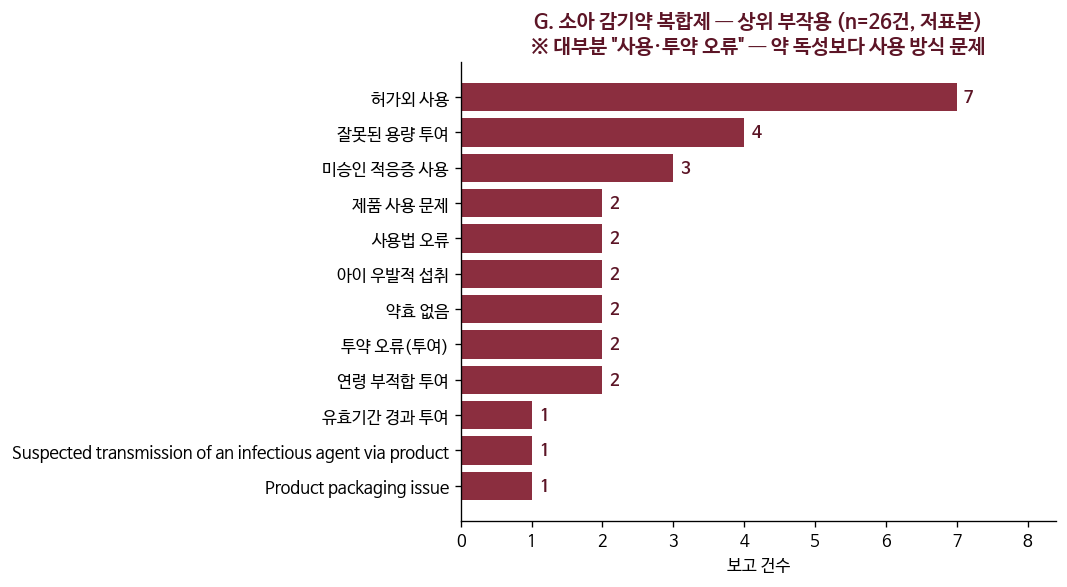

총 반응 연인원 44 건 (보고당 평균 1.7개)
reactions
Off label use                                                7
Incorrect dose administered                                  4
Product use in unapproved indication                         3
Product use issue                                            2
Wrong technique in product usage process                     2
Accidental exposure to product by child                      2
Drug ineffective                                             2
Product administration error                                 2
Product administered to patient of inappropriate age         2
Expired product administered                                 1
Suspected transmission of an infectious agent via product    1
Product packaging issue                                      1


In [4]:
#부작용 프로파일  -------------------------------
KR = {'Off label use':'허가외 사용','Product use in unapproved indication':'미승인 적응증 사용',
 'Accidental overdose':'우발적 과량','Overdose':'과다복용','Drug ineffective':'약효 없음','Vomiting':'구토',
 'Product use issue':'제품 사용 문제','Incorrect dose administered':'잘못된 용량 투여',
 'Inappropriate schedule of drug administration':'투약 일정 부적절','Accidental exposure to product by child':'아이 우발적 섭취',
 'Medication error':'투약 오류','Pyrexia':'발열','Rash':'발진','Wrong technique in product usage process':'사용법 오류',
 'Product administered to patient of inappropriate age':'연령 부적합 투여','Product administration error':'투약 오류(투여)',
 'Abdominal pain upper':'상복부 통증','Dysgeusia':'미각 이상','Expired product administered':'유효기간 경과 투여'}
rx = g['reactions'].fillna('').str.split(';').explode().str.strip()
rx = rx[rx!='']
top = rx.value_counts().head(12)
fig, ax = plt.subplots(figsize=(9,5))
ax.barh([KR.get(i,i) for i in top.index][::-1], top.values[::-1], color=MAIN)
for i,v in enumerate(top.values[::-1]): ax.text(v+0.1,i,str(v),va='center',fontweight='bold',color=BURG[4])
ax.set_xlabel('보고 건수'); ax.set_xlim(0, top.max()*1.2)
ax.set_title(f'G. 소아 감기약 복합제 — 상위 부작용 (n={len(g)}건, 저표본)\n※ 대부분 "사용·투약 오류" — 약 독성보다 사용 방식 문제',
             fontsize=12, fontweight='bold', color=BURG[4])
plt.tight_layout(); plt.show()
print('총 반응 연인원', len(rx), '건 (보고당 평균 %.1f개)' % (len(rx)/len(g)))
print(rx.value_counts().head(12).to_string())

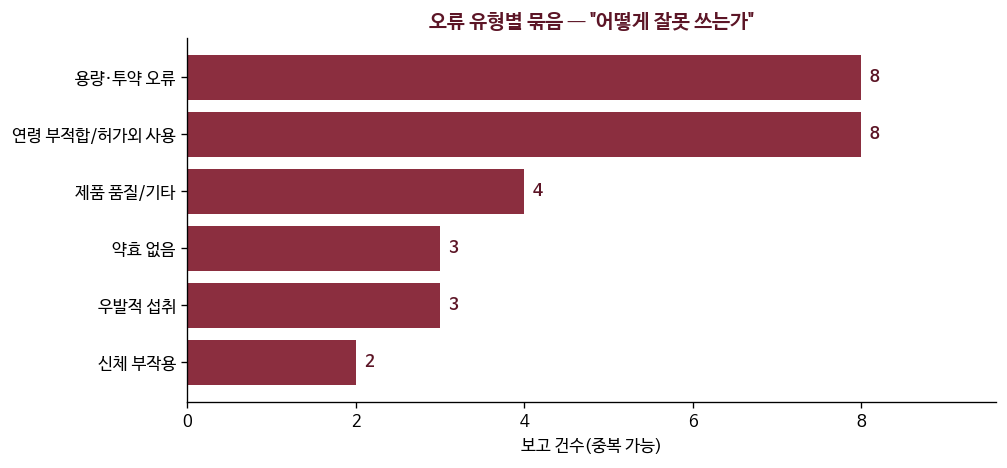

연령 부적합/허가외 사용    8
용량·투약 오류         8
제품 품질/기타         4
우발적 섭취           3
약효 없음            3
신체 부작용           2


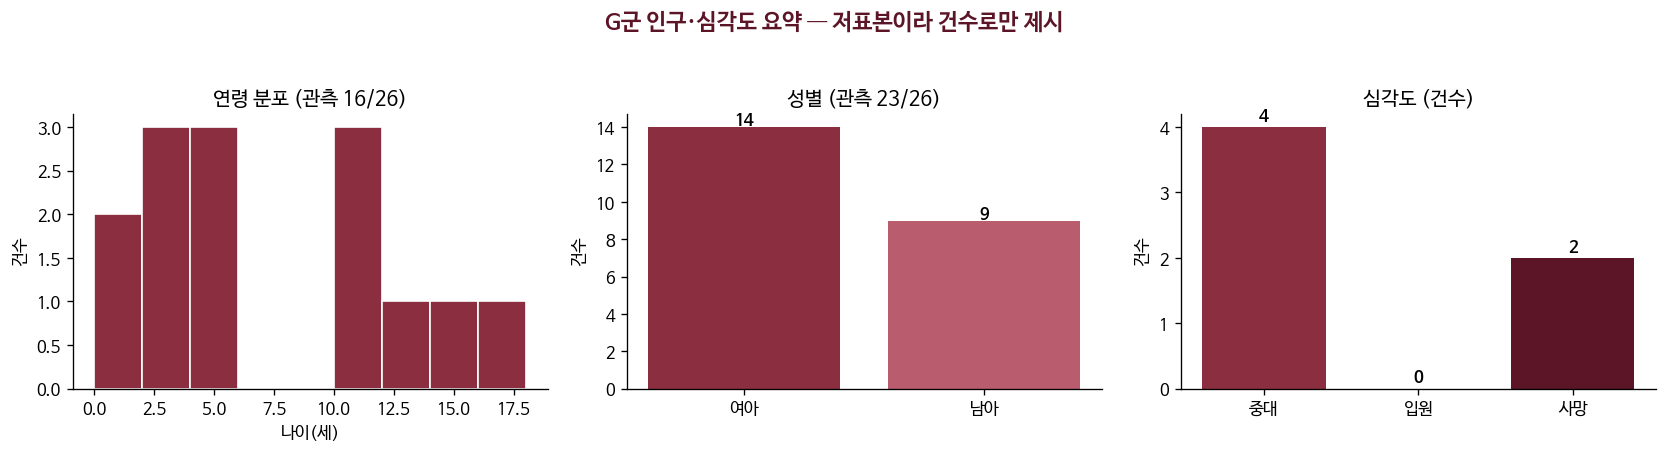

중대 4 · 입원 0 · 사망 2 (n=26)
체중 관측 12/26건 — 결측이 많아 통계 결론 불가, 관측값만 표시
체중(kg): [10.4, 14.5, 20.4, 31.8, 34.0, 35.0, 41.3, 43.1, 43.1, 46.3, 51.7, 89.4]


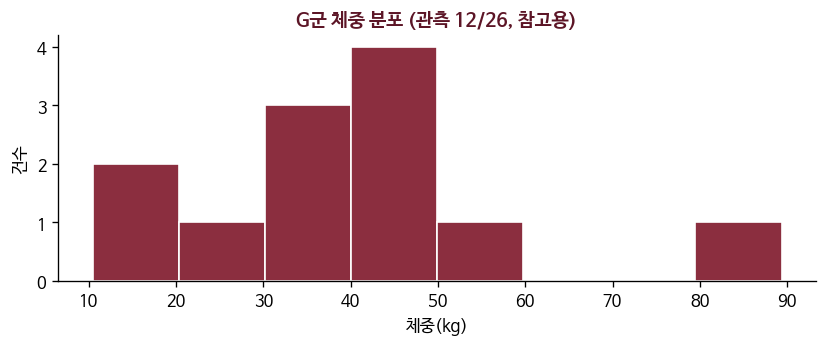

In [5]:
#오류 유형 그룹핑 (소비자 메시지용) -------------------------
# 사용·투약 오류를 소비자 관점 카테고리로 묶기
rxU = g['reactions'].fillna('').str.upper()
groups = {
 '연령 부적합/허가외 사용': r'OFF LABEL|UNAPPROVED INDICATION|INAPPROPRIATE AGE',
 '용량·투약 오류'        : r'INCORRECT DOSE|WRONG TECHNIQUE|ADMINISTRATION ERROR|MEDICATION ERROR|INAPPROPRIATE SCHEDULE|DOSE OMISSION',
 '우발적 섭취'           : r'ACCIDENTAL EXPOSURE|ACCIDENTAL OVERDOSE|POISON',
 '제품 품질/기타'        : r'PRODUCT USE ISSUE|PRODUCT QUALITY|EXPIRED|PACKAGING',
 '신체 부작용'           : r'VOMIT|ABDOMINAL|RASH|PYREXIA|SOMNOLENCE|DYSGEUSIA',
 '약효 없음'             : r'INEFFECTIVE|EFFECT INCOMPLETE',
}
gc = {k: rxU.str.contains(p, regex=True, na=False).sum() for k,p in groups.items()}
gc = pd.Series(gc).sort_values()
fig, ax = plt.subplots(figsize=(8.5,4))
ax.barh(gc.index, gc.values, color=MAIN)
for i,v in enumerate(gc.values): ax.text(v+0.1,i,str(v),va='center',fontweight='bold',color=BURG[4])
ax.set_xlabel('보고 건수(중복 가능)'); ax.set_xlim(0, gc.max()*1.2)
ax.set_title('오류 유형별 묶음 — "어떻게 잘못 쓰는가"', fontsize=12, fontweight='bold', color=BURG[4])
plt.tight_layout(); plt.show()
print(gc.sort_values(ascending=False).to_string())

 #인구·심각도 요약 (건수) ----------------------------------
fig, axs = plt.subplots(1,3, figsize=(14,3.6))
if g['age'].notna().sum() > 0:
    axs[0].hist(g['age'].dropna(), bins=range(0,20,2), color=MAIN, edgecolor='white')
    axs[0].set_title(f"연령 분포 (관측 {g['age'].notna().sum()}/26)")
    axs[0].set_xlabel('나이(세)'); axs[0].set_ylabel('건수')
sx = g['sex'].value_counts()
axs[1].bar([{'M':'남아','F':'여아'}.get(k,k) for k in sx.index], sx.values, color=[BURG[3],BURG[2]])
for i,v in enumerate(sx.values): axs[1].text(i,v+0.1,str(v),ha='center',fontweight='bold')
axs[1].set_title(f'성별 (관측 {g["sex"].notna().sum()}/26)'); axs[1].set_ylabel('건수')
sev = [g['serious_bin'].sum(), g['hosp'].sum(), g['fatal'].sum()]
axs[2].bar(['중대','입원','사망'], sev, color=[BURG[3],BURG[2],BURG[4]])
for i,v in enumerate(sev): axs[2].text(i,v+0.1,str(v),ha='center',fontweight='bold')
axs[2].set_title('심각도 (건수)'); axs[2].set_ylabel('건수')
fig.suptitle('G군 인구·심각도 요약 — 저표본이라 건수로만 제시', fontsize=13.5, fontweight='bold', color=BURG[4], y=1.04)
plt.tight_layout(); plt.show()
print('중대 %d · 입원 %d · 사망 %d (n=26)' % tuple(sev))


#체중 축 (소아 용량의 핵심) — 관측분만, 참고용 --------------
# 소아약은 체중 기반 용량이라 체중↔과량이 직결. 단 결측 많아 참고 수준.
w = g.dropna(subset=['weight'])
print(f'체중 관측 {len(w)}/26건 — 결측이 많아 통계 결론 불가, 관측값만 표시')
if len(w) > 0:
    print('체중(kg):', sorted(w['weight'].round(1).tolist()))
    fig, ax = plt.subplots(figsize=(7,3))
    ax.hist(w['weight'], bins=8, color=MAIN, edgecolor='white')
    ax.set_xlabel('체중(kg)'); ax.set_ylabel('건수')
    ax.set_title(f'G군 체중 분포 (관측 {len(w)}/26, 참고용)', fontsize=11.5, fontweight='bold', color=BURG[4])
    plt.tight_layout(); plt.show()

In [6]:
#소비자 인사이트 요약표 (데이터 + 문헌 방향) ----------------
# ※ 아래 문헌은 기관·주제 수준 (정확한 서지정보는 원문 확인 권장).
#   웹 검색을 켜면 정확한 출처를 붙일 수 있음.
insight = pd.DataFrame({
 '데이터 신호(건수)': ['허가외/연령부적합 (7+2)','용량·투약 오류 (4+2)','아이 우발적 섭취 (2)',
                 '약효 없음 (2)','사망 (2)'],
 '소비자 메시지': [
   '4세 미만(특히 2세 미만)에 임의 투여 말 것',
   '정확한 계량기구 사용, 영아용/소아용 농도 혼동 주의',
   '아이 손 닿지 않는 곳 보관',
   '경구 비충혈제거 효과는 제한적일 수 있음',
   '중복 감기약(아세트아미노펜 중복→간) 금지, 이상 시 즉시 진료'],
 '뒷받침 문헌(기관·주제)': [
   'FDA 2008 소아 OTC 감기약 권고 / AAP 권고',
   'FDA 아세트아미노펜 소아 농도 표준화(2011경)',
   'CDC 소아 우발적 섭취 / 안전보관',
   'FDA 경구 페닐레프린 효과 결론(2023)',
   'CDC MMWR 영아 사망 보고'],
})


print(insight.to_string(index=False))

     데이터 신호(건수)                             소비자 메시지                   뒷받침 문헌(기관·주제)
허가외/연령부적합 (7+2)          4세 미만(특히 2세 미만)에 임의 투여 말 것 FDA 2008 소아 OTC 감기약 권고 / AAP 권고
 용량·투약 오류 (4+2)       정확한 계량기구 사용, 영아용/소아용 농도 혼동 주의    FDA 아세트아미노펜 소아 농도 표준화(2011경)
  아이 우발적 섭취 (2)                     아이 손 닿지 않는 곳 보관            CDC 소아 우발적 섭취 / 안전보관
      약효 없음 (2)              경구 비충혈제거 효과는 제한적일 수 있음        FDA 경구 페닐레프린 효과 결론(2023)
         사망 (2) 중복 감기약(아세트아미노펜 중복→간) 금지, 이상 시 즉시 진료               CDC MMWR 영아 사망 보고
